# Natural Scene Classification Using CNNs and Transfer Learning
**Problem Statement**

This project aims to classify natural scene images into six categories: buildings, forest, glacier, mountain, sea, and street. The objective is to compare the performance of a custom convolutional neural network and a transfer learning model based on ResNet18.

**Goals**
- Explore and preprocess the Intel image dataset
- Build a baseline CNN for image classification
- Apply transfer learning with ResNet18
- Compare model performance using accuracy, loss curves, and confusion matrix

## Data Loading and Preprocessing

The Intel Image Classification dataset consists of natural scene images categorized into six classes: buildings, forest, glacier, mountain, sea, and street. 

To prepare the data for model training, images are resized to a fixed dimension of 150 × 150 pixels and normalized using ImageNet statistics. Normalization ensures that pixel values are scaled appropriately, which helps stabilize training and improve convergence.

The dataset is split into training, validation, and test sets. The training set is used to learn model parameters, the validation set is used for tuning and monitoring performance, and the test set is reserved for final evaluation.

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

Set reproducibility, device and paths

In [2]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

train_dir = "data/seg_train/seg_train"
test_dir = "data/seg_test/seg_test"

print("Train path exists:", os.path.exists(train_dir))
print("Test path exists:", os.path.exists(test_dir))

Device: cpu
Train path exists: True
Test path exists: True


Transforms and dataset objects

In [3]:
transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

full_train_dataset = datasets.ImageFolder(train_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

class_names = full_train_dataset.classes

print("Classes:", class_names)
print("Number of training images:", len(full_train_dataset))
print("Number of test images:", len(test_dataset))

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of training images: 14034
Number of test images: 3000


Train/validation split

In [4]:
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)
)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))

Train size: 11227
Validation size: 2807


In [5]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [6]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Class names:", class_names)

Image batch shape: torch.Size([32, 3, 150, 150])
Label batch shape: torch.Size([32])
Class names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## Data Exploration

To better understand the dataset, a sample of images from the training set is visualized below. This helps verify that the images are loaded correctly and provides insight into the visual characteristics of each class.

Visualize sample images

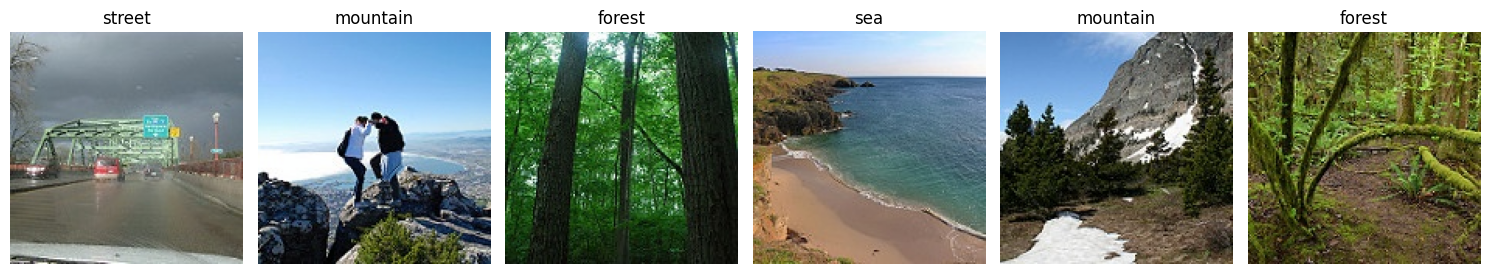

In [7]:
def imshow(img):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

fig, axes = plt.subplots(1, 6, figsize=(15, 4))

for i in range(6):
    axes[i].imshow(imshow(images[i].cpu()))
    axes[i].set_title(class_names[labels[i].item()])
    axes[i].axis("off")

plt.tight_layout()
plt.show()


The sample images show clear differences across categories. For example, forest images contain dense vegetation, while sea images exhibit large water bodies. However, some classes such as glacier and mountain appear visually similar, which may pose challenges for classification.

## Class Distribution

Understanding the distribution of images across classes is important to ensure that the dataset is balanced. An imbalanced dataset can bias the model toward more frequent classes.

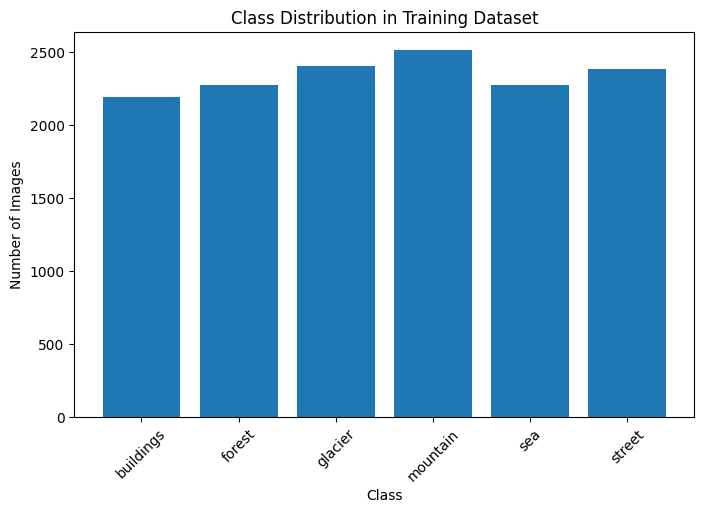

In [8]:
targets = full_train_dataset.targets
class_counts = pd.Series(targets).value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(class_names, class_counts)
plt.title("Class Distribution in Training Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

The class distribution appears relatively balanced across all categories. This is beneficial for training, as the model is less likely to become biased toward any single class.

## Baseline Model: Convolutional Neural Network (CNN)

A simple convolutional neural network is implemented as a baseline model. CNNs are well-suited for image classification tasks because they can automatically learn spatial features such as edges, textures, and shapes.

The architecture consists of multiple convolutional layers followed by ReLU activations and max-pooling layers to progressively extract higher-level features. A fully connected layer is used at the end to perform classification across the six scene categories.

In [9]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=6):
        super(SimpleCNN, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 18 * 18, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [10]:
cnn_model = SimpleCNN(num_classes=len(class_names)).to(device)
print(cnn_model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=20736, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=6, bias=True)
  )
)


Training and validation functions

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [12]:
def evaluate_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

## Training the CNN Model

The CNN model is trained using the cross-entropy loss function and the Adam optimizer. Model performance is tracked using both training and validation accuracy and loss over multiple epochs.

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

num_epochs = 5

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(cnn_model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate_model(cnn_model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f}")

Epoch 1/5
Train Loss: 0.9377, Train Acc: 0.6391
Val Loss:   0.7093, Val Acc:   0.7496
Epoch 2/5
Train Loss: 0.6279, Train Acc: 0.7741
Val Loss:   0.5573, Val Acc:   0.8009
Epoch 3/5
Train Loss: 0.4771, Train Acc: 0.8286
Val Loss:   0.5624, Val Acc:   0.8073
Epoch 4/5
Train Loss: 0.3735, Train Acc: 0.8683
Val Loss:   0.5048, Val Acc:   0.8237
Epoch 5/5
Train Loss: 0.2852, Train Acc: 0.8977
Val Loss:   0.5377, Val Acc:   0.8190


Plot training curves

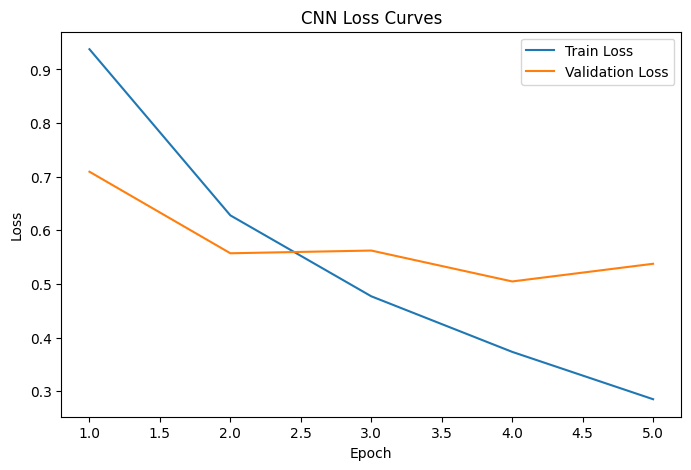

In [14]:
epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Validation Loss")
plt.title("CNN Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

The training loss decreases steadily over epochs, indicating that the model is learning meaningful patterns from the data. The validation loss initially decreases but begins to fluctuate after a few epochs, suggesting the onset of overfitting.

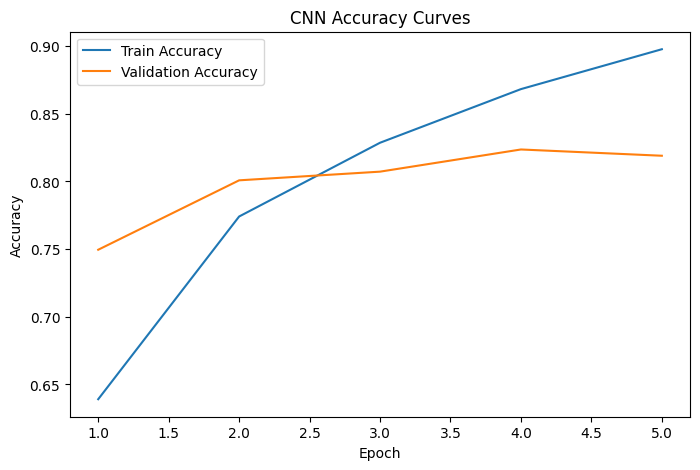

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_accs, label="Train Accuracy")
plt.plot(epochs_range, val_accs, label="Validation Accuracy")
plt.title("CNN Accuracy Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Training accuracy improves consistently, reaching close to 90%. However, validation accuracy plateaus around 82–83%, indicating that the model does not generalize as well to unseen data. This gap between training and validation performance suggests mild overfitting.

## CNN Model Evaluation

The performance of the CNN model is evaluated on the test dataset using a confusion matrix and classification metrics such as precision, recall, and F1-score.

In [16]:
def get_predictions(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    return np.array(all_labels), np.array(all_preds)

In [17]:
true_labels, pred_labels = get_predictions(cnn_model, test_loader, device)

print(classification_report(true_labels, pred_labels, target_names=class_names))

              precision    recall  f1-score   support

   buildings       0.85      0.74      0.79       437
      forest       0.91      0.97      0.94       474
     glacier       0.84      0.76      0.80       553
    mountain       0.73      0.86      0.79       525
         sea       0.85      0.81      0.83       510
      street       0.84      0.84      0.84       501

    accuracy                           0.83      3000
   macro avg       0.84      0.83      0.83      3000
weighted avg       0.83      0.83      0.83      3000



The overall test accuracy of the CNN model is approximately 83%. While this is a strong result for a simple model, there is room for improvement, particularly in distinguishing visually similar classes.

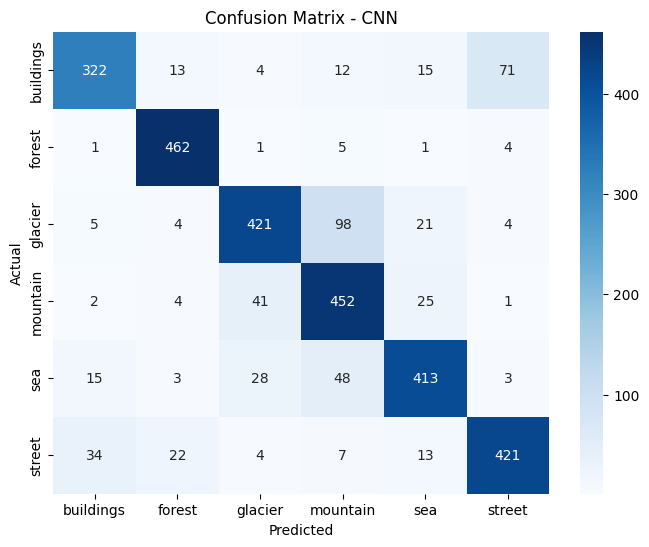

In [18]:
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - CNN")
plt.show()

The confusion matrix reveals that the model performs well on classes such as forest and street, which have distinctive visual patterns. However, confusion is observed between glacier and mountain, as well as between buildings and street. These misclassifications are likely due to similarities in visual features between these categories.

## Transfer Learning with ResNet18

To improve performance, a pretrained ResNet18 model is used. Transfer learning leverages features learned from large-scale datasets such as ImageNet, allowing the model to generalize better.

In this implementation, the convolutional layers of ResNet18 are frozen, and only the final fully connected layer is retrained to adapt to the six scene categories.

In [20]:
resnet_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in resnet_model.parameters():
    param.requires_grad = False

resnet_model.fc = nn.Linear(resnet_model.fc.in_features, len(class_names))
resnet_model = resnet_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet_model.fc.parameters(), lr=0.001)

In [21]:
num_epochs = 5

train_losses_res, val_losses_res = [], []
train_accs_res, val_accs_res = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(resnet_model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate_model(resnet_model, val_loader, criterion, device)
    
    train_losses_res.append(train_loss)
    val_losses_res.append(val_loss)
    train_accs_res.append(train_acc)
    val_accs_res.append(val_acc)
    
    print(f"Epoch {epoch+1}")
    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1
Train Acc: 0.8105 | Val Acc: 0.8671
Epoch 2
Train Acc: 0.8670 | Val Acc: 0.8871
Epoch 3
Train Acc: 0.8777 | Val Acc: 0.8881
Epoch 4
Train Acc: 0.8800 | Val Acc: 0.8938
Epoch 5
Train Acc: 0.8817 | Val Acc: 0.8945


In [25]:
true_labels_res, pred_labels_res = get_predictions(resnet_model, test_loader, device)

from sklearn.metrics import classification_report, accuracy_score

print(classification_report(true_labels_res, pred_labels_res, target_names=class_names))

resnet_test_acc = accuracy_score(true_labels_res, pred_labels_res)
print("ResNet Test Accuracy:", resnet_test_acc)

              precision    recall  f1-score   support

   buildings       0.88      0.93      0.91       437
      forest       0.99      0.98      0.98       474
     glacier       0.89      0.76      0.82       553
    mountain       0.79      0.86      0.83       525
         sea       0.88      0.96      0.92       510
      street       0.94      0.88      0.91       501

    accuracy                           0.89      3000
   macro avg       0.90      0.90      0.89      3000
weighted avg       0.89      0.89      0.89      3000

ResNet Test Accuracy: 0.8913333333333333


The ResNet18 model achieves significantly higher validation accuracy compared to the baseline CNN. This improvement demonstrates the effectiveness of transfer learning in extracting more robust and discriminative features from images.

## Model Comparison

To evaluate the effectiveness of both approaches, the performance of the baseline CNN and the ResNet18 model is compared.

In [24]:
comparison = pd.DataFrame({
    "Model": ["Simple CNN", "ResNet18"],
    "Final Train Accuracy": [0.8977, 0.8817],
    "Best Validation Accuracy": [0.8237, 0.8945],
    "Test Accuracy": [0.83, resnet_test_acc]
})

comparison

,Model,Final Train Accuracy,Best Validation Accuracy,Test Accuracy
0,Simple CNN,0.8977,0.8237,0.830000
1,ResNet18,0.8817,0.8945,0.891333


The ResNet18 model outperforms the custom CNN in terms of validation and test accuracy. While the CNN achieves high training accuracy, it suffers from mild overfitting and lower generalization performance.

In contrast, ResNet18 benefits from pretrained feature extraction, allowing it to better distinguish between visually similar classes. This results in improved overall performance and more consistent classification across categories.

These findings highlight the importance of transfer learning in image classification tasks, especially when dealing with complex visual patterns.

## Conclusion

This project demonstrates the application of deep learning techniques for image classification. A baseline CNN model achieved strong performance, but exhibited some overfitting and difficulty distinguishing similar classes.

By applying transfer learning with ResNet18, performance improved significantly, highlighting the advantage of leveraging pretrained models.

Future improvements could include data augmentation, fine-tuning deeper layers of the pretrained model, and experimenting with more advanced architectures.

Overall, the results confirm that transfer learning is a powerful approach for improving image classification performance.